In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('/kaggle/input/datasets/saurabhbadole/zomato-delivery-operations-analytics-dataset/Zomato Dataset.csv')
df.head(5)


,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weather_conditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken (min)
0,0xcdcd,DEHRES17DEL01,36.0,4.2,30.327968,78.046106,30.397968,78.116106,12-02-2022,21:55,22:10,Fog,Jam,2,Snack,motorcycle,3.0,No,Metropolitian,46
1,0xd987,KOCRES16DEL01,21.0,4.7,10.003064,76.307589,10.043064,76.347589,13-02-2022,14:55,15:05,Stormy,High,1,Meal,motorcycle,1.0,No,Metropolitian,23
2,0x2784,PUNERES13DEL03,23.0,4.7,18.562450,73.916619,18.652450,74.006619,04-03-2022,17:30,17:40,Sandstorms,Medium,1,Drinks,scooter,1.0,No,Metropolitian,21
3,0xc8b6,LUDHRES15DEL02,34.0,4.3,30.899584,75.809346,30.919584,75.829346,13-02-2022,09:20,09:30,Sandstorms,Low,0,Buffet,motorcycle,0.0,No,Metropolitian,20
4,0xdb64,KNPRES14DEL02,24.0,4.7,26.463504,80.372929,26.593504,80.502929,14-02-2022,19:50,20:05,Fog,Jam,1,Snack,scooter,1.0,No,Metropolitian,41


In [3]:
df.shape

(45584, 20)

In [4]:
df.columns

Index(['ID', 'Delivery_person_ID', 'Delivery_person_Age',
       'Delivery_person_Ratings', 'Restaurant_latitude',
       'Restaurant_longitude', 'Delivery_location_latitude',
       'Delivery_location_longitude', 'Order_Date', 'Time_Orderd',
       'Time_Order_picked', 'Weather_conditions', 'Road_traffic_density',
       'Vehicle_condition', 'Type_of_order', 'Type_of_vehicle',
       'multiple_deliveries', 'Festival', 'City', 'Time_taken (min)'],
      dtype='object')

In [5]:
df.columns = [col.lower() for col in df.columns]
df.rename(columns = {"time_taken (min)" : "time_taken_min"},inplace = True)
df.columns

Index(['id', 'delivery_person_id', 'delivery_person_age',
       'delivery_person_ratings', 'restaurant_latitude',
       'restaurant_longitude', 'delivery_location_latitude',
       'delivery_location_longitude', 'order_date', 'time_orderd',
       'time_order_picked', 'weather_conditions', 'road_traffic_density',
       'vehicle_condition', 'type_of_order', 'type_of_vehicle',
       'multiple_deliveries', 'festival', 'city', 'time_taken_min'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45584 entries, 0 to 45583
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id                           45584 non-null  object 
 1   delivery_person_id           45584 non-null  object 
 2   delivery_person_age          43730 non-null  float64
 3   delivery_person_ratings      43676 non-null  float64
 4   restaurant_latitude          45584 non-null  float64
 5   restaurant_longitude         45584 non-null  float64
 6   delivery_location_latitude   45584 non-null  float64
 7   delivery_location_longitude  45584 non-null  float64
 8   order_date                   45584 non-null  object 
 9   time_orderd                  43853 non-null  object 
 10  time_order_picked            45584 non-null  object 
 11  weather_conditions           44968 non-null  object 
 12  road_traffic_density         44983 non-null  object 
 13  vehicle_conditio

In [7]:
df.dtypes

id                              object
delivery_person_id              object
delivery_person_age            float64
delivery_person_ratings        float64
restaurant_latitude            float64
restaurant_longitude           float64
delivery_location_latitude     float64
delivery_location_longitude    float64
order_date                      object
time_orderd                     object
time_order_picked               object
weather_conditions              object
road_traffic_density            object
vehicle_condition                int64
type_of_order                   object
type_of_vehicle                 object
multiple_deliveries            float64
festival                        object
city                            object
time_taken_min                   int64
dtype: object

In [8]:
df['order_date'] = pd.to_datetime(df["order_date"],format="%d-%m-%Y")
df.dtypes

id                                     object
delivery_person_id                     object
delivery_person_age                   float64
delivery_person_ratings               float64
restaurant_latitude                   float64
restaurant_longitude                  float64
delivery_location_latitude            float64
delivery_location_longitude           float64
order_date                     datetime64[ns]
time_orderd                            object
time_order_picked                      object
weather_conditions                     object
road_traffic_density                   object
vehicle_condition                       int64
type_of_order                          object
type_of_vehicle                        object
multiple_deliveries                   float64
festival                               object
city                                   object
time_taken_min                          int64
dtype: object

In [9]:
df.describe(include = np.number)

,delivery_person_age,delivery_person_ratings,restaurant_latitude,restaurant_longitude,delivery_location_latitude,delivery_location_longitude,vehicle_condition,multiple_deliveries,time_taken_min
count,43730.000000,43676.000000,45584.000000,45584.000000,45584.000000,45584.000000,45584.000000,44591.000000,45584.000000
mean,29.566911,4.633774,17.017948,70.229684,17.465480,70.844161,1.023385,0.744635,26.293963
std,5.815064,0.334744,8.185674,22.885575,7.335562,21.120578,0.839055,0.572510,9.384298
min,15.000000,1.000000,-30.905562,-88.366217,0.010000,0.010000,0.000000,0.000000,10.000000
25%,25.000000,4.500000,12.933284,73.170000,12.988453,73.280000,0.000000,0.000000,19.000000
50%,30.000000,4.700000,18.551440,75.897963,18.633934,76.002574,1.000000,1.000000,26.000000
75%,35.000000,4.900000,22.728163,78.044095,22.785049,78.107044,2.000000,1.000000,32.000000
max,50.000000,6.000000,30.914057,88.433452,31.054057,88.563452,3.000000,3.000000,54.000000


In [10]:
df.describe(include = "object")

,id,delivery_person_id,time_orderd,time_order_picked,weather_conditions,road_traffic_density,type_of_order,type_of_vehicle,festival,city
count,45584,45584,43853,45584,44968,44983,45584,45584,45356,44384
unique,45584,1320,176,193,6,4,4,4,2,3
top,0xcdcd,JAPRES11DEL02,21:55,21:30,Fog,Low,Snack,motorcycle,No,Metropolitian
freq,1,67,461,495,7653,15476,11530,26429,44460,34087


In [11]:
(df.isnull().sum()/len(df)) * 100

id                             0.000000
delivery_person_id             0.000000
delivery_person_age            4.067217
delivery_person_ratings        4.185679
restaurant_latitude            0.000000
restaurant_longitude           0.000000
delivery_location_latitude     0.000000
delivery_location_longitude    0.000000
order_date                     0.000000
time_orderd                    3.797385
time_order_picked              0.000000
weather_conditions             1.351351
road_traffic_density           1.318445
vehicle_condition              0.000000
type_of_order                  0.000000
type_of_vehicle                0.000000
multiple_deliveries            2.178396
festival                       0.500176
city                           2.632503
time_taken_min                 0.000000
dtype: float64

In [25]:
# Observation: Less than 5% null values present in 45000 rows, hence we can drop the null values 
df.dropna(inplace = True)
(df.isnull().sum()/len(df)) * 100

id                             0.0
delivery_person_id             0.0
delivery_person_age            0.0
delivery_person_ratings        0.0
restaurant_latitude            0.0
restaurant_longitude           0.0
delivery_location_latitude     0.0
delivery_location_longitude    0.0
order_date                     0.0
time_orderd                    0.0
time_order_picked              0.0
weather_conditions             0.0
road_traffic_density           0.0
vehicle_condition              0.0
type_of_order                  0.0
type_of_vehicle                0.0
multiple_deliveries            0.0
festival                       0.0
city                           0.0
time_taken_min                 0.0
order_month                    0.0
delivery_person_age_bin        0.0
peak_hours                     0.0
distance_km                    0.0
pickup_delay_min               0.0
dtype: float64

In [13]:
# creating some new features
df['order_month'] = df['order_date'].dt.month

df['delivery_person_age_bin'] = pd.cut(
    df['delivery_person_age'],
    bins=[18, 25, 35, 45, 60],
    labels=['18-25', '26-35', '36-45', '46-60'],
    include_lowest=True
)

In [14]:
df.columns

Index(['id', 'delivery_person_id', 'delivery_person_age',
       'delivery_person_ratings', 'restaurant_latitude',
       'restaurant_longitude', 'delivery_location_latitude',
       'delivery_location_longitude', 'order_date', 'time_orderd',
       'time_order_picked', 'weather_conditions', 'road_traffic_density',
       'vehicle_condition', 'type_of_order', 'type_of_vehicle',
       'multiple_deliveries', 'festival', 'city', 'time_taken_min',
       'order_month', 'delivery_person_age_bin'],
      dtype='object')

In [16]:
df['time_orderd'] = pd.to_datetime(df['time_orderd'], format='%H:%M', errors='coerce')

def is_peak_hour(df):
    hour = pd.to_datetime(df['time_orderd']).hour
    return 1 if (11 <= hour < 14) or (17 <= hour < 21) else 0

df['peak_hours'] = df.apply(is_peak_hour, axis=1)


In [26]:
(df.isnull().sum()/len(df)) * 100
df.shape

(33402, 25)

In [22]:
df['time_order_picked'] = pd.to_datetime(df['time_order_picked'], format='%H:%M', errors='coerce')
df['pickup_delay_min'] = (
    df['time_order_picked'] -
    df['time_orderd']
).dt.total_seconds() / 60

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33402 entries, 0 to 33401
Data columns (total 25 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   id                           33402 non-null  object        
 1   delivery_person_id           33402 non-null  object        
 2   delivery_person_age          33402 non-null  float64       
 3   delivery_person_ratings      33402 non-null  float64       
 4   restaurant_latitude          33402 non-null  float64       
 5   restaurant_longitude         33402 non-null  float64       
 6   delivery_location_latitude   33402 non-null  float64       
 7   delivery_location_longitude  33402 non-null  float64       
 8   order_date                   33402 non-null  datetime64[ns]
 9   time_orderd                  33402 non-null  datetime64[ns]
 10  time_order_picked            33402 non-null  datetime64[ns]
 11  weather_conditions           33402 non-nu

ValueError: num must be an integer with 1 <= num <= 12, not 13

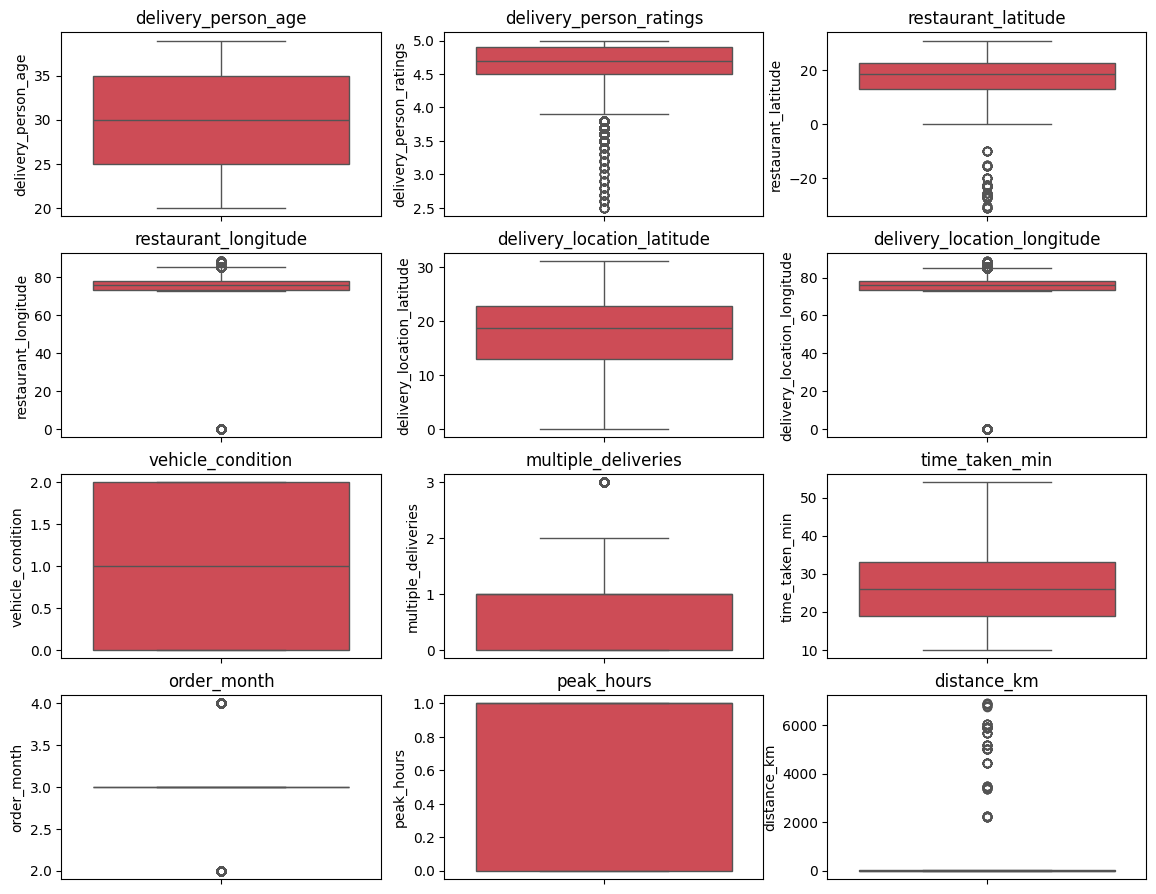

In [27]:
# Outlier Handling
numeric_columns = df.select_dtypes(include=["number"])

plt.figure(figsize=(14,11))
for i,col in enumerate (numeric_columns.columns):
  plt.subplot(4,3,i+1)
  sns.boxplot(df[col],color="#E23744")
  plt.title(col)
plt.tight_layout()
plt.show()

In [28]:
def identify_outliers(data):
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return data[(data < lower_bound) | (data > upper_bound)]

outlier_counts = {}  

for col in numeric_columns.columns:
    outliers = identify_outliers(numeric_columns[col])
    outlier_counts[col] = len(outliers)

for col, count in outlier_counts.items():
    print(f"Count of outliers present in {col}: {count}")
    print(f"% Count of outliers present in {col}: {count/ len(df)*100}\n")

Count of outliers present in delivery_person_age: 0
% Count of outliers present in delivery_person_age: 0.0

Count of outliers present in delivery_person_ratings: 898
% Count of outliers present in delivery_person_ratings: 2.688461768756362

Count of outliers present in restaurant_latitude: 120
% Count of outliers present in restaurant_latitude: 0.35925992455541583

Count of outliers present in restaurant_longitude: 3271
% Count of outliers present in restaurant_longitude: 9.792826776839709

Count of outliers present in delivery_location_latitude: 0
% Count of outliers present in delivery_location_latitude: 0.0

Count of outliers present in delivery_location_longitude: 4736
% Count of outliers present in delivery_location_longitude: 14.178791689120413

Count of outliers present in vehicle_condition: 0
% Count of outliers present in vehicle_condition: 0.0

Count of outliers present in multiple_deliveries: 275
% Count of outliers present in multiple_deliveries: 0.8233039937728279

Count 

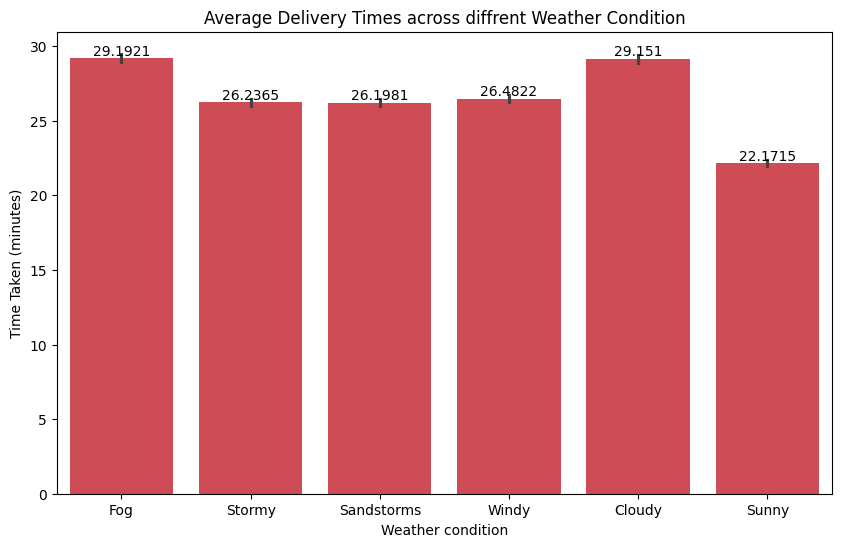

In [32]:
# different factors affecting time 
plt.figure(figsize =(10,6))
ax = sns.barplot(x="weather_conditions", y="time_taken_min", data=df,color="#E23744")

for container in ax.containers:
    ax.bar_label(container)

plt.title("Average Delivery Times across diffrent Weather Condition")
plt.xlabel("Weather condition")
plt.ylabel("Time Taken (minutes)")
plt.show()

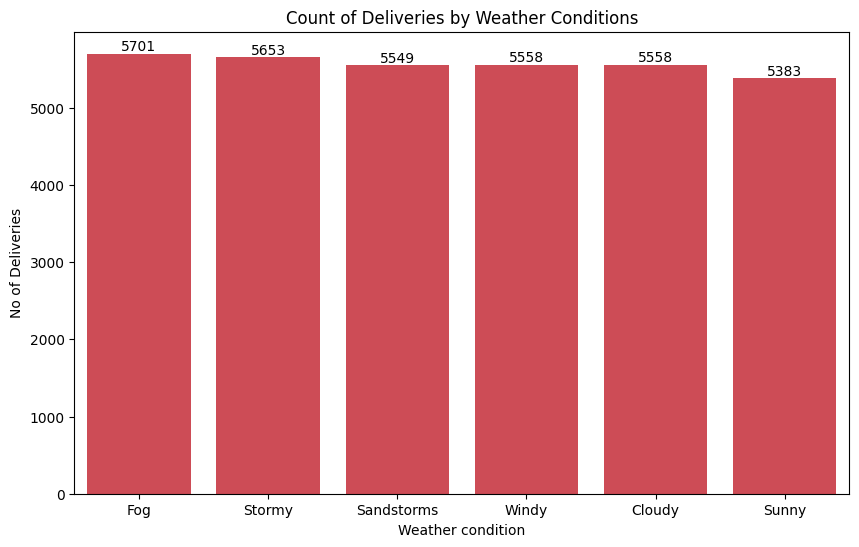

In [33]:
plt.figure(figsize=(10, 6))
ax = sns.countplot(x = "weather_conditions", data=df,color="#E23744")

for container in ax.containers:
    ax.bar_label(container)

plt.title("Count of Deliveries by Weather Conditions")
plt.xlabel("Weather condition")
plt.ylabel("No of Deliveries")
plt.show()

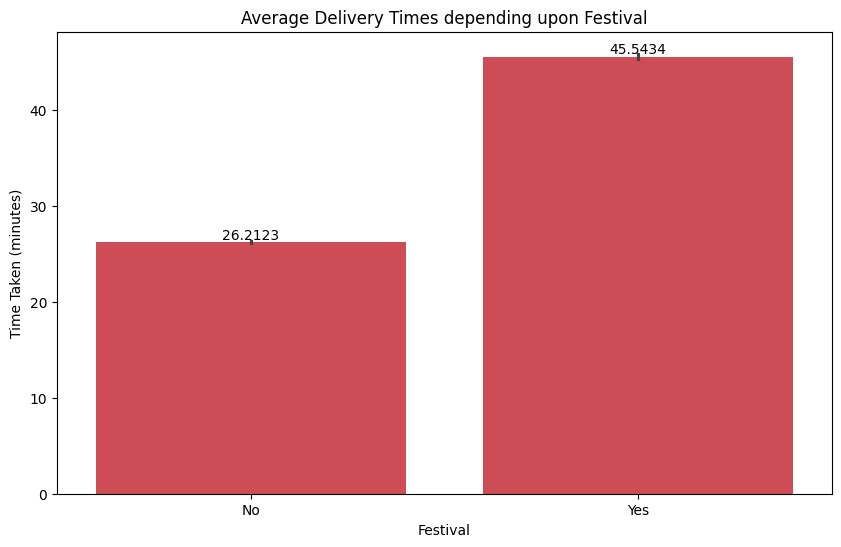

In [34]:
plt.figure(figsize =(10,6))
ax = sns.barplot(x="festival", y="time_taken_min", data=df,color="#E23744")

for container in ax.containers:
    ax.bar_label(container)

plt.title("Average Delivery Times depending upon Festival")
plt.xlabel("Festival")
plt.ylabel("Time Taken (minutes)")
plt.show()

/tmp/ipykernel_58/4290973378.py:2: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#E23744'` for the same effect.

  ax = sns.barplot(x="type_of_vehicle", y="time_taken_min",hue="peak_hours", data=df,color="#E23744")


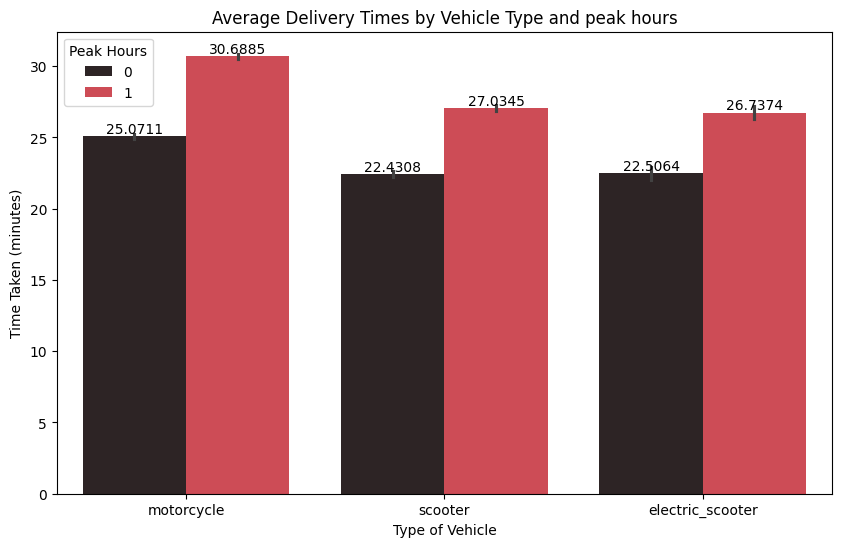

In [35]:
plt.figure(figsize =(10,6))
ax = sns.barplot(x="type_of_vehicle", y="time_taken_min",hue="peak_hours", data=df,color="#E23744")

for container in ax.containers:
    ax.bar_label(container)

plt.title("Average Delivery Times by Vehicle Type and peak hours")
plt.xlabel("Type of Vehicle")
plt.ylabel("Time Taken (minutes)")
plt.legend(title = "Peak Hours")
plt.show()

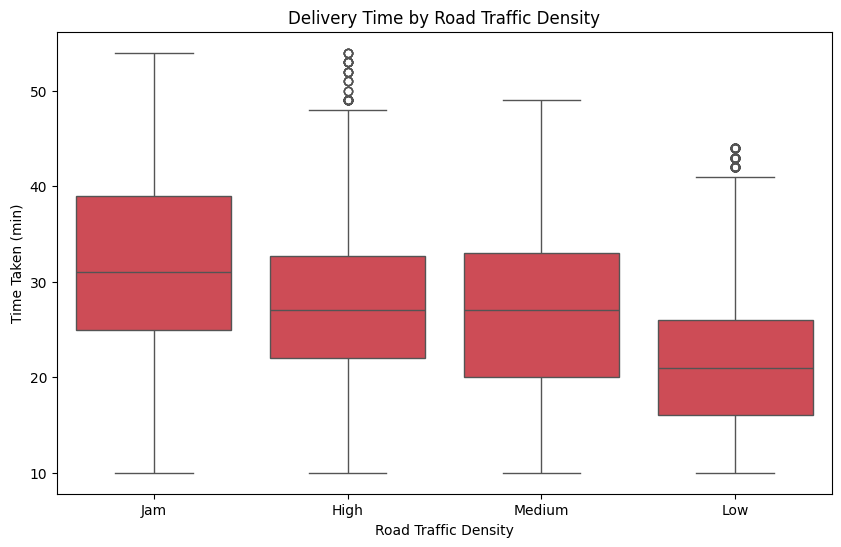

In [36]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='road_traffic_density', y='time_taken_min', data=df,color="#E23744")
plt.title('Delivery Time by Road Traffic Density')
plt.xlabel('Road Traffic Density')
plt.ylabel('Time Taken (min)')
plt.show()

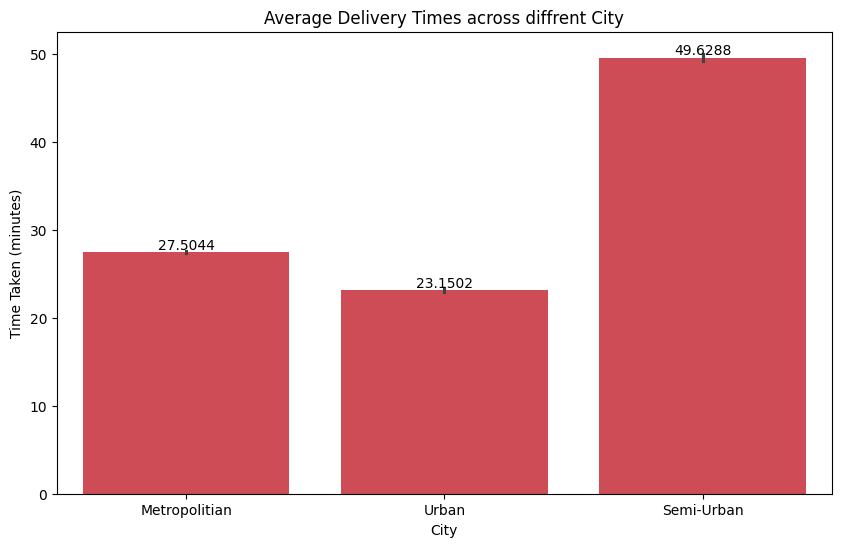

In [37]:
plt.figure(figsize =(10,6))
ax = sns.barplot(x="city", y="time_taken_min", data=df,color="#E23744")

for container in ax.containers:
    ax.bar_label(container)

plt.title("Average Delivery Times across diffrent City")
plt.xlabel("City")
plt.ylabel("Time Taken (minutes)")
plt.show()

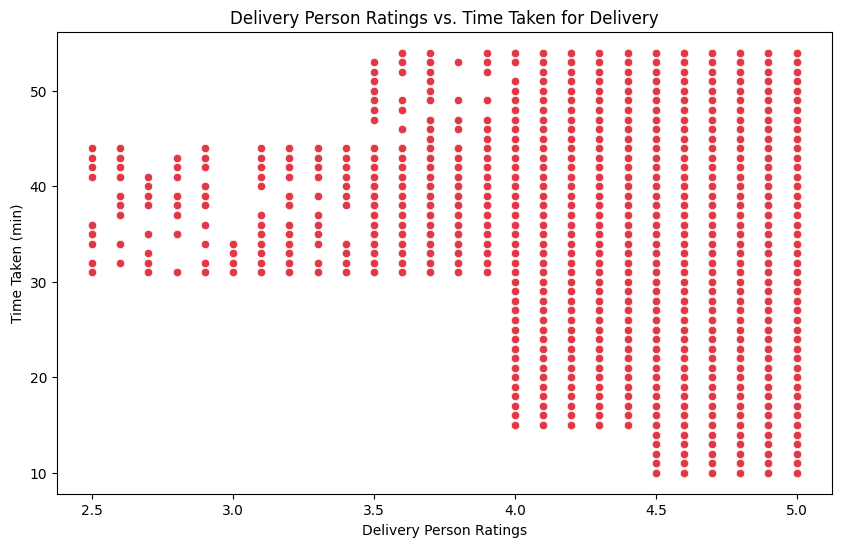

In [38]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x="delivery_person_ratings", y="time_taken_min", data=df,color="#E23744")
plt.title("Delivery Person Ratings vs. Time Taken for Delivery")
plt.xlabel("Delivery Person Ratings")
plt.ylabel("Time Taken (min)")
plt.show()

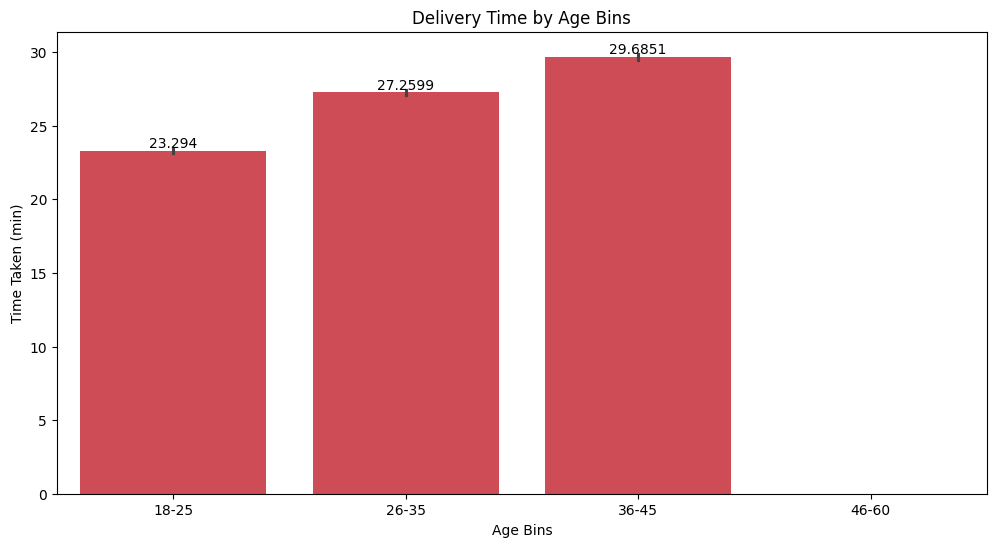

In [40]:
plt.figure(figsize=(12, 6))
ax = sns.barplot(x="delivery_person_age_bin", y="time_taken_min",  data=df,color="#E23744")
for container in ax.containers:
    ax.bar_label(container)
plt.title("Delivery Time by Age Bins")
plt.xlabel("Age Bins")
plt.ylabel("Time Taken (min)")
plt.show()

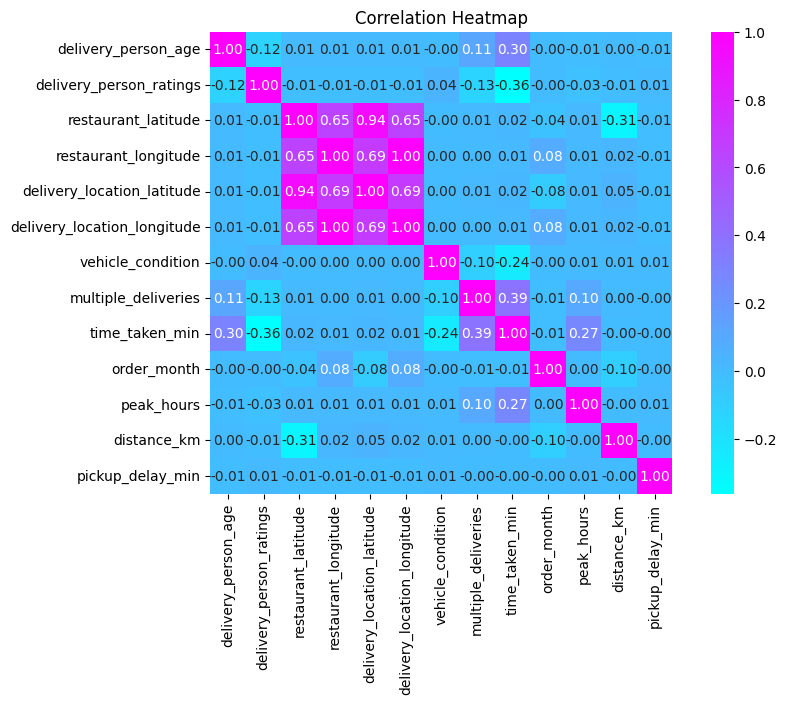

In [50]:
plt.figure(figsize = (10,6))
sns.heatmap(numeric_columns.corr(), cmap='cool', annot=True, fmt='.2f', square=True)
plt.title('Correlation Heatmap')
plt.show()

In [52]:
# Hypothesis Testing
# Hypothesis 1: 
# H0 = There is no difference in average delivery times between high-rated and low-rated delivery persons.
# H1 = Higher-rated delivery persons have shorter average delivery times.

from scipy.stats import ttest_ind

median_rating = df["delivery_person_ratings"].median()

high_rated = df[df["delivery_person_ratings"] > median_rating]["time_taken_min"]
low_rated = df[df["delivery_person_ratings"] <= median_rating]["time_taken_min"]

t_stat, p_value = ttest_ind(high_rated, low_rated)

print(f"T-statistic: {t_stat},\nP-value: {p_value}")

alpha = 0.05
if p_value < alpha:
    print("Result: Reject Null Hypothesis")
    print("Conclusion: There is a significant difference in average delivery times between high-rated and low-rated delivery persons. Specifically, higher-rated delivery persons tend to have shorter average delivery times. This suggests that higher ratings may correlate with better performance, possibly due to factors such as experience, efficiency, or customer service skills.")
else:
    print("Result: Fail to Reject Null Hypothesis")
    print("Conclusion: There is no significant difference in average delivery times between high-rated and low-rated delivery persons. This implies that the ratings assigned to delivery personnel may not significantly influence delivery efficiency, suggesting that other factors may play a more critical role in determining delivery times.")

T-statistic: -31.873067145158444,
P-value: 1.2436498054089246e-219
Result: Reject Null Hypothesis
Conclusion: There is a significant difference in average delivery times between high-rated and low-rated delivery persons. Specifically, higher-rated delivery persons tend to have shorter average delivery times. This suggests that higher ratings may correlate with better performance, possibly due to factors such as experience, efficiency, or customer service skills.


In [53]:
# Hypothesis 2
#H0 = There is no difference in average delivery times across different weather conditions.
#H1 = Average delivery times differ based on weather conditions.

from scipy.stats import f_oneway


Cloudy     = df[df["weather_conditions"]=="Cloudy"]["time_taken_min"]
Fog        = df[df["weather_conditions"]=="Fog"]["time_taken_min"]
Sandstorms = df[df["weather_conditions"]=="Sandstorms"]["time_taken_min"]
Stormy     = df[df["weather_conditions"]=="Stormy"]["time_taken_min"]
Sunny      = df[df["weather_conditions"]=="Sunny"]["time_taken_min"]
Windy      = df[df["weather_conditions"]=="Windy"]["time_taken_min"]

f_stat, p_value = f_oneway(Cloudy,Fog,Sandstorms,Stormy,Sunny,Windy)
print(f"T-statistic: {f_stat},\nP-value: {p_value}")

alpha = 0.05
if p_value < alpha:
    print("Result: Reject Null Hypothesis")
    print("Conclusion: There is a significant difference in average delivery times based on weather conditions. This suggests that various weather conditions impact delivery efficiency, indicating that some conditions may lead to longer delivery times than others.")
else:
    print("Result: Fail to Reject Null Hypothesis")
    print("Conclusion: There is no significant difference in average delivery times across different weather conditions. This implies that weather may not be a critical factor influencing delivery times, suggesting that other variables might play a more significant role in affecting delivery efficiency.")

T-statistic: 442.8133625180162,
P-value: 0.0
Result: Reject Null Hypothesis
Conclusion: There is a significant difference in average delivery times based on weather conditions. This suggests that various weather conditions impact delivery efficiency, indicating that some conditions may lead to longer delivery times than others.


In [54]:
# Hypothesis 3
# h0 = There is no difference in average delivery times between young (younger than 30) and old (30 or older) delivery persons.
# h1 = There is a significant difference in average delivery times between young and old delivery persons.

df["Age_Group"] = ["Younger" if age <= 30 else "Older" for age in df["delivery_person_age"]]

younger_deliveries = df[df["Age_Group"] == "Younger"]["time_taken_min"]
older_deliveries = df[df["Age_Group"] == "Older"]["time_taken_min"]

t_stat, p_value = ttest_ind(younger_deliveries, older_deliveries)
print(f"T-statistic: {t_stat},\nP-value: {p_value}")

alpha = 0.05
if p_value < alpha:
    print("Result: Reject Null Hypothesis")
    print("Conclusion: There is a significant difference in average delivery times between young and old delivery persons. This suggests that age may impact delivery performance.")
else:
    print("Result: Fail to Reject Null Hypothesis")
    print("Conclusion: There is no significant difference in average delivery times between young and old delivery persons. This suggests that age does not have a notable effect on delivery performance.")

T-statistic: -60.659563367394405,
P-value: 0.0
Result: Reject Null Hypothesis
Conclusion: There is a significant difference in average delivery times between young and old delivery persons. This suggests that age may impact delivery performance.


In [ ]:
#Hypothesis 4
# H0 = There is no difference in average delivery times across different levels of road traffic density.
# H1 = There is a significant difference in average delivery times across different levels of road traffic density.

Low    = df[df["road_traffic_density"]=="Low"]["time_taken_min"]
Jam    = df[df["road_traffic_density"]=="Jam"]["time_taken_min"]
Medium = df[df["road_traffic_density"]=="Medium"]["time_taken_min"]
High   = df[df["road_traffic_density"]=="High"]["time_taken_min"]

f_stat, p_value = f_oneway(Low,Jam,Medium,High)
print(f"T-statistic: {f_stat},\nP-value: {p_value}")

alpha = 0.05
if p_value < alpha:
    print("Result: Reject Null Hypothesis")
    print("Conclusion: There is a significant difference in average delivery times across different levels of road traffic density. This indicates that traffic conditions play a crucial role in determining delivery efficiency, with varying densities affecting how quickly deliveries are completed.")
else:
    print("Result: Fail to Reject Null Hypothesis")
    print("Conclusion: There is no significant difference in average delivery times across different levels of road traffic density. This suggests that road traffic density may not be a key factor influencing delivery times, indicating that other variables could be more impactful.")

T-statistic: 2525.003835519124,
P-value: 0.0
Result: Reject Null Hypothesis
Conclusion: There is a significant difference in average delivery times across different levels of road traffic density. This indicates that traffic conditions play a crucial role in determining delivery efficiency, with varying densities affecting how quickly deliveries are completed.


In [ ]:
# Hypothesis 5
# H0 = There is no difference in average delivery times between deliveries made during festivals and those made during non-festival periods.
# H1 = Average delivery times are significantly longer for deliveries made during festivals compared to those made during non-festival periods.

festival_deliveries = df[df["festival"] == "Yes"]["time_taken_min"]
non_festival_deliveries = df[df["festival"] == "No"]["time_taken_min"]

t_stat, p_value = ttest_ind(festival_deliveries, non_festival_deliveries)

print(f"T-statistic: {t_stat},\nP-value: {p_value}")

alpha = 0.05
if p_value < alpha:
    print("Result: Reject Null Hypothesis")
    print("Conclusion: This suggests that delivery times are indeed significantly longer during festival periods, potentially due to increased traffic, higher demand, or other contributing factors.")
else:
    print("Result: Fail to Reject Null Hypothesis")
    print("Conclusion: This implies that there is no significant difference in delivery times during festivals compared to non-festival periods, indicating that festivals may not substantially impact delivery efficiency")


T-statistic: 55.71331742369077,
P-value: 0.0
Result: Reject Null Hypothesis
Conclusion: This suggests that delivery times are indeed significantly longer during festival periods, potentially due to increased traffic, higher demand, or other contributing factors.


In [ ]:
# Hypothesis 6
# H0 = There is no difference in average delivery times among different types of vehicles.
# H1 = There is a significant difference in average delivery times among different types of vehicles.

motorcycle       = df[df["type_of_vehicle"]=="motorcycle"]["time_taken_min"]
scooter          = df[df["type_of_vehicle"]=="scooter"]["time_taken_min"]
electric_scooter = df[df["type_of_vehicle"]=="electric_scooter"]["time_taken_min"]

f_stat, p_value = f_oneway(motorcycle,scooter,electric_scooter)
print(f"T-statistic: {f_stat},\nP-value: {p_value}")

alpha = 0.05
if p_value < alpha:
    print("Result: Reject Null Hypothesis")
    print("Conclusion: There is a significant difference in average delivery times among different types of vehicles.")
else:
    print("Result: Fail to Reject Null Hypothesis")
    print("Conclusion: There is no difference in average delivery times among different types of vehicles.")

In [ ]:
# Hypothesis 7
# H0 = There is no difference in average delivery times among different cities.
# H1 = There is a significant difference in average delivery times among different cities.

Metropolitian  = df[df["city"]=="Metropolitian"]["time_taken_min"]
Urban          = df[df["city"]=="Urban"]["time_taken_min"]
Semi_Urban     = df[df["city"]=="Semi-Urban"]["time_taken_min"]

f_stat, p_value = f_oneway(Metropolitian,Urban,Semi_Urban)
print(f"T-statistic: {f_stat},\nP-value: {p_value}")

alpha = 0.05
if p_value < alpha:
    print("Result: Reject Null Hypothesis")
    print("Conclusion: There is a significant difference in average delivery times among different cities.")
else:
    print("Result: Fail to Reject Null Hypothesis")
    print("Conclusion: There is no difference in average delivery times among different cities.")

T-statistic: 1102.766967259589,
P-value: 0.0
Result: Reject Null Hypothesis
Conclusion: There is a significant difference in average delivery times among different cities.
